# Build Task Bank — Classification

Builds **ClassificationTask** objects (defined in `models/task.py`) for three subtasks:

| Subtask | Dataset | Labels | Split |
|---------|---------|--------|-------|
| Sentiment | [SetFit/sst5](https://huggingface.co/datasets/SetFit/sst5) | 5 (very negative → very positive) | test |
| Sentiment | [fancyzhx/amazon_polarity](https://huggingface.co/datasets/fancyzhx/amazon_polarity) | 2 (negative, positive) | test |
| Topic | [fancyzhx/dbpedia_14](https://huggingface.co/datasets/fancyzhx/dbpedia_14) | 14 (Company, Artist, …) | test |
| Topic | [community-datasets/yahoo_answers_topics](https://huggingface.co/datasets/community-datasets/yahoo_answers_topics) | 10 (Health, Sports, …) | test |
| Intent | [sonos-nlu-benchmark/snips_built_in_intents](https://huggingface.co/datasets/sonos-nlu-benchmark/snips_built_in_intents) | 10 (GetWeather, BookRestaurant, …) | train (only split) |
| Intent | [clinc/clinc_oos](https://huggingface.co/datasets/clinc/clinc_oos) | 151 (150 intents + OOS) | test |

Each dataset is saved to its own JSONL file. A balanced combined sample is also produced.

## 1. Imports & config

In [1]:
import json
import random
import sys
from datetime import date
from pathlib import Path
from typing import Literal

import nltk
import textstat
from datasets import load_dataset

sys.path.append(str(Path("__file__").resolve().parent.parent))
from models.task import ClassificationTask, Task
from utils.pipeline_utils import infer_domain, annotate_pending, _NEEDS_REVIEW

# ── Config ────────────────────────────────────────────────────────────────────
TASK_BANK   = Path("../task_bank")
SEED        = 42

OUT_SST5    = TASK_BANK / "clf_sst5_tasks.jsonl"
OUT_AMAZON  = TASK_BANK / "clf_amazon_tasks.jsonl"
OUT_DBPEDIA = TASK_BANK / "clf_dbpedia_tasks.jsonl"
OUT_YAHOO   = TASK_BANK / "clf_yahoo_tasks.jsonl"
OUT_SNIPS   = TASK_BANK / "clf_snips_tasks.jsonl"
OUT_CLINC   = TASK_BANK / "clf_clinc_tasks.jsonl"
OUT_COMBINED = TASK_BANK / "clf_combined_tasks.jsonl"

# Samples per dataset (None = use all)
N_SST5    = None
N_AMAZON  = None
N_DBPEDIA = None
N_YAHOO   = None
N_SNIPS   = None   # only 328 rows total — use all
N_CLINC   = None
N_COMBINED = 1000    # drawn from each dataset into the combined file

/home/sristi/.pyenv/versions/venv_langchain_3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FileNotFoundError: [Errno 2] No such file or directory

## 2. Load datasets

In [2]:
sst5    = load_dataset("SetFit/sst5",                                  split="test")
amazon  = load_dataset("fancyzhx/amazon_polarity",                     split="test")
dbpedia = load_dataset("fancyzhx/dbpedia_14",                          split="test")
yahoo   = load_dataset("community-datasets/yahoo_answers_topics",      split="test")
snips   = load_dataset("sonos-nlu-benchmark/snips_built_in_intents",   split="train")
clinc   = load_dataset("clinc/clinc_oos",                 "small",     split="test")

print(f"SST-5    : {len(sst5):>7,} rows | columns: {sst5.column_names}")
print(f"Amazon   : {len(amazon):>7,} rows | columns: {amazon.column_names}")
print(f"DBpedia  : {len(dbpedia):>7,} rows | columns: {dbpedia.column_names}")
print(f"Yahoo    : {len(yahoo):>7,} rows | columns: {yahoo.column_names}")
print(f"SNIPS    : {len(snips):>7,} rows | columns: {snips.column_names}")
print(f"CLINC    : {len(clinc):>7,} rows | columns: {clinc.column_names}")

Repo card metadata block was not found. Setting CardData to empty.


SST-5    :   2,210 rows | columns: ['text', 'label', 'label_text']
Amazon   : 400,000 rows | columns: ['label', 'title', 'content']
DBpedia  :  70,000 rows | columns: ['label', 'title', 'content']
Yahoo    :  60,000 rows | columns: ['id', 'topic', 'question_title', 'question_content', 'best_answer']
SNIPS    :     328 rows | columns: ['text', 'label']
CLINC    :   5,500 rows | columns: ['text', 'intent']


In [3]:
import pandas as pd

for name, ds in [("SST-5", sst5), ("Amazon", amazon), ("DBpedia", dbpedia),
                 ("Yahoo", yahoo), ("SNIPS", snips), ("CLINC", clinc)]:
    print(f"\n{'='*40}  {name} {'='*40}")
    display(ds.to_pandas().head(3))


========================================  SST-5 ========================================


,text,label,label_text
0,"no movement , no yuks , not much of anything .",1,negative
1,"a gob of drivel so sickly sweet , even the eag...",0,very negative
2,` how many more voyages can this limping but d...,2,neutral



========================================  Amazon ========================================


,label,title,content
0,1,Great CD,My lovely Pat has one of the GREAT voices of h...
1,1,One of the best game music soundtracks - for a...,Despite the fact that I have only played a sma...
2,0,Batteries died within a year ...,I bought this charger in Jul 2003 and it worke...



========================================  DBpedia ========================================


...

,id,topic,question_title,question_content,best_answer
0,0,8,What makes friendship click?,How does the spark keep going?,good communication is what does it. Can you m...
1,1,1,Why does Zebras have stripes?,What is the purpose or those stripes? Who do t...,this provides camouflage - predator vision is ...
2,2,3,What did the itsy bitsy sipder climb up?,,waterspout



========================================  SNIPS ========================================


,text,label
0,Share my location with Hillary's sister,5
1,Send my current location to my father,5
2,Share my current location with Jim,5



========================================  CLINC ========================================


,text,intent
0,how would you say fly in italian,61
1,what's the spanish word for pasta,61
2,how would they say butter in zambia,61


## 3. Shared helpers

In [5]:
import textstat

_NEGATIONS = {
    "not", "no", "never", "nobody", "nothing", "nowhere", "neither", "nor",
    "don't", "doesn't", "didn't", "isn't", "aren't", "wasn't", "weren't",
    "won't", "wouldn't", "couldn't", "shouldn't", "can't", "cannot",
    "hardly", "barely", "scarcely", "without",
}


def assign_difficulty_clf(
    text: str,
    label_set: list[str],
) -> Literal["easy", "medium", "hard"]:
    """
    Five signals weighted for classification difficulty:

    35%  label-set size      — more classes -> harder to discriminate.
                               Normalised: 2 labels -> 0.0, 150 labels -> 1.0.

    35%  text length         — U-shaped: both very short texts (insufficient
                               signal) and very long texts (signal buried in
                               noise) are harder than a medium-length passage.
                               Sweet-spot ~75 tokens; score = |n - 75| / 200.

    30%  lexical diversity   — type-token ratio (unique / total tokens).
                               Higher TTR means the key discriminating words
                               are more spread out and harder to identify.

    Thresholds:  score < 0.35 -> easy  |  < 0.65 -> medium  |  else -> hard
    """
    tokens   = text.split()
    n        = max(len(tokens), 1)

    # 1. Label-set size
    label_score = min((len(label_set) - 2) / 148.0, 1.0)

    # 3. Text length — U-shaped around optimal = 75 tokens
    length_score = min(abs(n - 75) / 200.0, 1.0)

    # 4. Lexical diversity — type-token ratio
    ttr_score = len({t.lower() for t in tokens}) / n

    score = (
        0.35 * label_score
        + 0.35 * length_score
        + 0.30 * ttr_score
    )
    if score < 0.35:
        return "easy"
    if score < 0.65:
        return "medium"
    return "hard"


def shuffle_sample(ds, n, seed=SEED):
    """Deterministic sample: shuffle with fixed seed then take first n rows."""
    shuffled = ds.shuffle(seed=seed)
    return shuffled.select(range(min(n, len(shuffled)))) if n is not None else shuffled

## 4. Sentiment — SST-5

Movie-review phrases from the Stanford Sentiment Treebank.
5-class ordinal sentiment: **very negative, negative, neutral, positive, very positive**.

In [6]:
SST5_LABELS = ["very negative", "negative", "neutral", "positive", "very positive"]

SST5_RUBRIC = (
    "Classify the sentiment of the following movie-review phrase on a 5-point scale.\n"
    "Valid labels (choose exactly one):\n"
    "  very negative -- strongly negative opinion, harsh criticism\n"
    "  negative      -- mildly negative, disappointed, or unenthusiastic\n"
    "  neutral       -- no clear sentiment, purely descriptive\n"
    "  positive      -- mildly positive, generally favourable\n"
    "  very positive -- strongly positive, enthusiastic praise\n\n"
    "Return a JSON object: {\"label\": str, \"confidence\": float (0-1), \"reasoning\": str}"
)


def sst5_row_to_task(row: dict, index: int) -> ClassificationTask:
    text = row["text"]
    return ClassificationTask(
        task_id    = f"clf_sst5_test_{index:06d}",
        difficulty = assign_difficulty_clf(text, SST5_LABELS),
        domain     = "entertainment",   # all SST examples are movie reviews
        input      = text,
        expected   = row["label_text"],
        label_set  = SST5_LABELS,
        rubric     = SST5_RUBRIC,
        metadata   = {
            "source"     : "SetFit/sst5",
            "split"      : "test",
            "original_id": index,
            "subtask"    : "sentiment",
            "date_added" : str(date.today()),
        },
    )


sst5_sample = shuffle_sample(sst5, N_SST5)
sst5_tasks  = [sst5_row_to_task(sst5_sample[i], i) for i in range(len(sst5_sample))]
print(f"SST-5: {len(sst5_tasks)} tasks")

SST-5: 2210 tasks


## 5. Sentiment — Amazon Polarity

Product reviews from Amazon. Binary sentiment: **negative, positive**.
Input is `title + " " + content` (review headline + body).

In [12]:
AMAZON_LABELS = ["negative", "positive"]

AMAZON_RUBRIC = (
    "Classify the sentiment of the following Amazon product review.\n"
    "Valid labels (choose exactly one):\n"
    "  negative -- the reviewer is dissatisfied with the product\n"
    "  positive -- the reviewer is satisfied with the product\n\n"
    "Return a JSON object: {\"label\": str, \"confidence\": float (0-1), \"reasoning\": str}"
)


def amazon_row_to_task(row: dict, index: int) -> ClassificationTask:
    text = f"{row['title']}. {row['content']}"
    return ClassificationTask(
        task_id    = f"clf_amazon_test_{index:06d}",
        difficulty = assign_difficulty_clf(text, AMAZON_LABELS),
        domain     = infer_domain(text),
        input      = text,
        expected   = AMAZON_LABELS[row["label"]],
        label_set  = AMAZON_LABELS,
        rubric     = AMAZON_RUBRIC,
        metadata   = {
            "source"     : "fancyzhx/amazon_polarity",
            "split"      : "test",
            "original_id": index,
            "subtask"    : "sentiment",
            "date_added" : str(date.today()),
        },
    )


amazon_sample = shuffle_sample(amazon, N_AMAZON)
amazon_tasks  = [amazon_row_to_task(amazon_sample[i], i) for i in range(len(amazon_sample))]
print(f"Amazon Polarity: {len(amazon_tasks)} tasks")

Amazon Polarity: 400000 tasks


## 6. Topic — DBpedia-14

Wikipedia abstracts labelled with 14 ontology classes.
Input is `title + ": " + content` (article title + opening paragraph).

In [13]:
DBPEDIA_LABELS = [
    "Company", "EducationalInstitution", "Artist", "Athlete", "OfficeHolder",
    "MeanOfTransportation", "Building", "NaturalPlace", "Village", "Animal",
    "Plant", "Album", "Film", "WrittenWork",
]

DBPEDIA_RUBRIC = (
    "Classify the Wikipedia article excerpt into exactly one of the 14 DBpedia ontology classes.\n"
    "Valid labels:\n"
    + "\n".join(f"  {l}" for l in DBPEDIA_LABELS)
    + "\n\nReturn a JSON object: {\"label\": str, \"confidence\": float (0-1), \"reasoning\": str}"
)


def dbpedia_row_to_task(row: dict, index: int) -> ClassificationTask:
    text = f"{row['title']}: {row['content']}"
    return ClassificationTask(
        task_id    = f"clf_dbpedia_test_{index:06d}",
        difficulty = assign_difficulty_clf(text, DBPEDIA_LABELS),
        domain     = infer_domain(text),
        input      = text,
        expected   = DBPEDIA_LABELS[row["label"]],
        label_set  = DBPEDIA_LABELS,
        rubric     = DBPEDIA_RUBRIC,
        metadata   = {
            "source"     : "fancyzhx/dbpedia_14",
            "split"      : "test",
            "original_id": index,
            "subtask"    : "topic",
            "date_added" : str(date.today()),
        },
    )


dbpedia_sample = shuffle_sample(dbpedia, N_DBPEDIA)
dbpedia_tasks  = [dbpedia_row_to_task(dbpedia_sample[i], i) for i in range(len(dbpedia_sample))]
print(f"DBpedia-14: {len(dbpedia_tasks)} tasks")

DBpedia-14: 70000 tasks


## 7. Topic — Yahoo Answers Topics

Community Q&A posts labelled with 10 broad topic categories.
Input combines question title, question body, and best answer.

In [14]:
YAHOO_LABELS = [
    "Society & Culture", "Science & Mathematics", "Health",
    "Education & Reference", "Computers & Internet", "Sports",
    "Business & Finance", "Entertainment & Music",
    "Family & Relationships", "Politics & Government",
]

YAHOO_RUBRIC = (
    "Classify the Yahoo Answers post into exactly one of the 10 topic categories.\n"
    "Valid labels:\n"
    + "\n".join(f"  {l}" for l in YAHOO_LABELS)
    + "\n\nReturn a JSON object: {\"label\": str, \"confidence\": float (0-1), \"reasoning\": str}"
)


def yahoo_row_to_task(row: dict, index: int) -> ClassificationTask:
    parts = [row["question_title"]]
    if row.get("question_content", "").strip():
        parts.append(row["question_content"])
    if row.get("best_answer", "").strip():
        parts.append(f"Best answer: {row['best_answer']}")
    text = " ".join(parts)
    return ClassificationTask(
        task_id    = f"clf_yahoo_test_{index:06d}",
        difficulty = assign_difficulty_clf(text, YAHOO_LABELS),
        domain     = infer_domain(text),
        input      = text,
        expected   = YAHOO_LABELS[row["topic"]],
        label_set  = YAHOO_LABELS,
        rubric     = YAHOO_RUBRIC,
        metadata   = {
            "source"     : "community-datasets/yahoo_answers_topics",
            "split"      : "test",
            "original_id": row.get("id", index),
            "subtask"    : "topic",
            "date_added" : str(date.today()),
        },
    )


yahoo_sample = shuffle_sample(yahoo, N_YAHOO)
yahoo_tasks  = [yahoo_row_to_task(yahoo_sample[i], i) for i in range(len(yahoo_sample))]
print(f"Yahoo Answers: {len(yahoo_tasks)} tasks")

Yahoo Answers: 60000 tasks


## 8. Intent — SNIPS Built-in Intents

Voice-assistant utterances with 10 intent classes.
Small dataset (328 rows) — use all of them.

In [15]:
SNIPS_LABELS = [
    "ComparePlaces", "RequestRide", "GetWeather", "SearchPlace",
    "GetPlaceDetails", "ShareCurrentLocation", "GetTrafficInformation",
    "BookRestaurant", "GetDirections", "ShareETA",
]

SNIPS_RUBRIC = (
    "Classify the user utterance into exactly one voice-assistant intent.\n"
    "Valid labels:\n"
    "  ComparePlaces          -- comparing two or more locations\n"
    "  RequestRide            -- booking or requesting a ride/taxi\n"
    "  GetWeather             -- asking about weather conditions\n"
    "  SearchPlace            -- finding a specific place or business\n"
    "  GetPlaceDetails        -- getting details about a known place\n"
    "  ShareCurrentLocation   -- sharing the user's current location\n"
    "  GetTrafficInformation  -- asking about traffic or road conditions\n"
    "  BookRestaurant         -- making a restaurant reservation\n"
    "  GetDirections          -- asking for navigation directions\n"
    "  ShareETA               -- sharing estimated time of arrival\n\n"
    "Return a JSON object: {\"label\": str, \"confidence\": float (0-1), \"reasoning\": str}"
)

_snips_id2label = dict(enumerate(SNIPS_LABELS))


def snips_row_to_task(row: dict, index: int) -> ClassificationTask:
    text = row["text"]
    return ClassificationTask(
        task_id    = f"clf_snips_train_{index:06d}",
        difficulty = assign_difficulty_clf(text, SNIPS_LABELS),
        domain     = infer_domain(text),
        input      = text,
        expected   = _snips_id2label[row["label"]],
        label_set  = SNIPS_LABELS,
        rubric     = SNIPS_RUBRIC,
        metadata   = {
            "source"     : "sonos-nlu-benchmark/snips_built_in_intents",
            "split"      : "train",
            "original_id": index,
            "subtask"    : "intent",
            "date_added" : str(date.today()),
        },
    )


snips_sample = shuffle_sample(snips, N_SNIPS)
snips_tasks  = [snips_row_to_task(snips_sample[i], i) for i in range(len(snips_sample))]
print(f"SNIPS: {len(snips_tasks)} tasks")

SNIPS: 328 tasks


## 9. Intent — CLINC OOS (small config)

Banking/travel/home-automation chatbot utterances.
151 classes: 150 in-scope intents + 1 out-of-scope (`oos`) class.
Uses the `small` config (balanced, 5,500-row test split).

In [16]:
# Build label list from the dataset's own ClassLabel feature
_clinc_feature  = clinc.features["intent"]
CLINC_LABELS    = _clinc_feature.names   # list of 151 strings, index = label id

CLINC_RUBRIC = (
    "Classify the user utterance into exactly one of the 151 CLINC intent categories, "
    "or 'oos' if it does not match any in-scope intent.\n"
    "The full label list is available in the task's label_set field.\n\n"
    "Return a JSON object: {\"label\": str, \"confidence\": float (0-1), \"reasoning\": str}"
)


def clinc_row_to_task(row: dict, index: int) -> ClassificationTask:
    text = row["text"]
    return ClassificationTask(
        task_id    = f"clf_clinc_test_{index:06d}",
        difficulty = assign_difficulty_clf(text, CLINC_LABELS),
        domain     = infer_domain(text),
        input      = text,
        expected   = CLINC_LABELS[row["intent"]],
        label_set  = list(CLINC_LABELS),
        rubric     = CLINC_RUBRIC,
        metadata   = {
            "source"     : "clinc/clinc_oos",
            "config"     : "small",
            "split"      : "test",
            "original_id": index,
            "subtask"    : "intent",
            "date_added" : str(date.today()),
        },
    )


clinc_sample = shuffle_sample(clinc, N_CLINC)
clinc_tasks  = [clinc_row_to_task(clinc_sample[i], i) for i in range(len(clinc_sample))]
print(f"CLINC OOS: {len(clinc_tasks)} tasks")

CLINC OOS: 5500 tasks


## 10. Human annotation pass

In [ ]:
all_dicts = {
    "SST-5"   : [t.model_dump() for t in sst5_tasks],
    "Amazon"  : [t.model_dump() for t in amazon_tasks],
    "DBpedia" : [t.model_dump() for t in dbpedia_tasks],
    "Yahoo"   : [t.model_dump() for t in yahoo_tasks],
    "SNIPS"   : [t.model_dump() for t in snips_tasks],
    "CLINC"   : [t.model_dump() for t in clinc_tasks],
}

for name, tasks in all_dicts.items():
    pending = sum(1 for t in tasks if t["domain"] == _NEEDS_REVIEW)
    if pending:
        print(f"{name}: {pending} tasks need annotation")
        annotate_pending(tasks)
    else:
        print(f"{name}: all domains auto-tagged")

SST-5: all domains auto-tagged
Amazon: 224171 tasks need annotation

  224171 task(s) need human annotation.
  Valid domains: ['politics', 'crime', 'sports', 'business', 'technology', 'health', 'entertainment', 'science', 'environment', 'general']
  Leave blank + Enter (or Ctrl+C) to cancel remaining → 'general'

[1/224171]  Damaged Product. The product works fine. I ordered the more exprensive one after I read reviews from others on Amazon. My husband likes the presser. It does a good job pressing his pants. However, it was damaged in the box when we received it. We decided it was too much trouble to send it back. The 


Cancelled — tagging remaining 224171 item(s) as 'general'.
DBpedia: 31520 tasks need annotation

  31520 task(s) need human annotation.
  Valid domains: ['politics', 'crime', 'sports', 'business', 'technology', 'health', 'entertainment', 'science', 'environment', 'general']
  Leave blank + Enter (or Ctrl+C) to cancel remaining → 'general'

[1/31520]  The April Witch: 

In [23]:
amazon_tasks[4]

ClassificationTask(task_id='clf_amazon_test_000004', difficulty='easy', domain='entertainment', input="Is the joke on me?. I hated this movie. It was so silly. The girl made the cult look more stupid than they already were. Come on? She was from the future??? I can't stop laughing. Maybe, I missed something. I don't think I did. When it first started, I said to myself: What am I watching this for? I thought it was stupid, stupid and then more stupid. I kept watching, trying to make sense of it, but to no avail. I didn't want to waste my $1.00 rental fee.", expected='negative', rubric='Classify the sentiment of the following Amazon product review.\nValid labels (choose exactly one):\n  negative -- the reviewer is dissatisfied with the product\n  positive -- the reviewer is satisfied with the product\n\nReturn a JSON object: {"label": str, "confidence": float (0-1), "reasoning": str}', metadata={'source': 'fancyzhx/amazon_polarity', 'split': 'test', 'original_id': 4, 'subtask': 'sentimen

## 11. Difficulty distribution

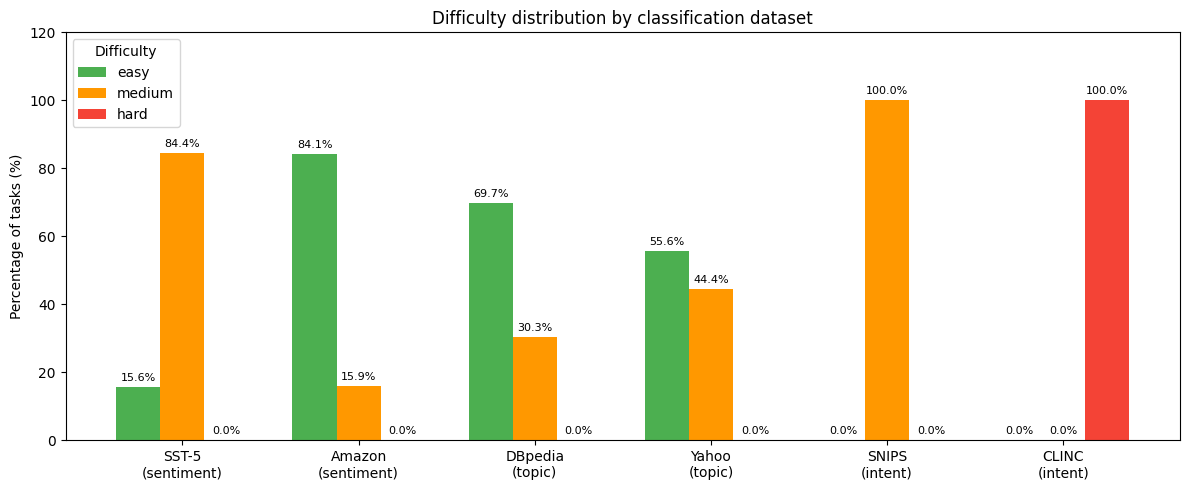


Dataset    Subtask        easy   medium   hard   total
--------------------------------------------------
SST-5      sentiment       344     1866      0    2210
Amazon     sentiment    336228    63772      0  400000
DBpedia    topic         48791    21209      0   70000
Yahoo      topic         33361    26639      0   60000
SNIPS      intent            0      328      0     328
CLINC      intent            0        1   5499    5500


In [18]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

subtask_colors = {"sentiment": "#2196f3", "topic": "#9c27b0", "intent": "#ff5722"}
subtasks = {
    "SST-5"   : "sentiment",
    "Amazon"  : "sentiment",
    "DBpedia" : "topic",
    "Yahoo"   : "topic",
    "SNIPS"   : "intent",
    "CLINC"   : "intent",
}

difficulties = ["easy", "medium", "hard"]
bar_colors   = {"easy": "#4caf50", "medium": "#ff9800", "hard": "#f44336"}

names = list(all_dicts.keys())
x     = np.arange(len(names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for j, diff in enumerate(difficulties):
    totals = [len(all_dicts[n]) for n in names]
    pcts   = [
        sum(1 for t in all_dicts[n] if t["difficulty"] == diff) / totals[i] * 100
        for i, n in enumerate(names)
    ]
    bars = ax.bar(x + j * width, pcts, width, label=diff, color=bar_colors[diff])
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(
    [f"{n}\n({subtasks[n]})" for n in names], fontsize=10
)
ax.set_ylabel("Percentage of tasks (%)")
ax.set_ylim(0, 120)
ax.set_title("Difficulty distribution by classification dataset")
ax.legend(title="Difficulty")
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Dataset':<10} {'Subtask':<12} {'easy':>6} {'medium':>8} {'hard':>6} {'total':>7}")
print("-" * 50)
for name, tasks in all_dicts.items():
    c = Counter(t["difficulty"] for t in tasks)
    print(f"{name:<10} {subtasks[name]:<12} {c['easy']:>6} {c['medium']:>8} {c['hard']:>6} {len(tasks):>7}")

## 12. Save to JSONL

In [ ]:
import random as _random

TASK_BANK.mkdir(parents=True, exist_ok=True)

save_map = [
    (OUT_SST5,    all_dicts["SST-5"]),
    (OUT_AMAZON,  all_dicts["Amazon"]),
    (OUT_DBPEDIA, all_dicts["DBpedia"]),
    (OUT_YAHOO,   all_dicts["Yahoo"]),
    (OUT_SNIPS,   all_dicts["SNIPS"]),
    (OUT_CLINC,   all_dicts["CLINC"]),
]

for out_path, tasks in save_map:
    with out_path.open("w", encoding="utf-8") as f:
        for task in tasks:
            f.write(json.dumps(task, ensure_ascii=False) + "\n")
    print(f"Saved {len(tasks):>4} tasks -> {out_path.name}")

In [27]:
# Combined balanced sample
_random.seed(SEED)
combined = [
    task
    for _, tasks in save_map
    for task in _random.sample(tasks, len(tasks) if N_COMBINED is None else min(N_COMBINED, len(tasks)))
]
_random.shuffle(combined)
with OUT_COMBINED.open("w", encoding="utf-8") as f:
    for task in combined:
        f.write(json.dumps(task, ensure_ascii=False) + "\n")
print(f"\nSaved {len(combined):>4} tasks -> {OUT_COMBINED.name}  (combined sample)")


Saved 5328 tasks -> clf_combined_tasks.jsonl  (combined sample)


## 13. Reload & validate round-trip

In [28]:
from pydantic import TypeAdapter

adapter = TypeAdapter(Task)

for out_path, _ in [*save_map, (OUT_COMBINED, None)]:
    loaded = []
    with out_path.open(encoding="utf-8") as f:
        for line in f:
            loaded.append(adapter.validate_json(line))
    ok = all(isinstance(t, ClassificationTask) for t in loaded)
    print(f"{out_path.name:<35} {len(loaded):>4} tasks  all ClassificationTask: {ok}")

clf_sst5_tasks.jsonl                2210 tasks  all ClassificationTask: True
clf_amazon_tasks.jsonl              400000 tasks  all ClassificationTask: True
clf_dbpedia_tasks.jsonl             70000 tasks  all ClassificationTask: True
clf_yahoo_tasks.jsonl               60000 tasks  all ClassificationTask: True
clf_snips_tasks.jsonl                328 tasks  all ClassificationTask: True
clf_clinc_tasks.jsonl               5500 tasks  all ClassificationTask: True
clf_combined_tasks.jsonl            5328 tasks  all ClassificationTask: True
